# GESLA data from tidal gauges around the world.

- Data was downloaded from [GESLA database](https://gesla787883612.wordpress.com/downloads/).
- Below, we show can to access the metadata, and load a tidal gauge next to Alexandria.

In [ ]:
import pandas as pd

gesla_info = pd.read_csv("inputs/sea_level/GESLA4_ALL.csv")
gesla_info[gesla_info.COUNTRY == "EGY"]

,FILE NAME,SITE NAME,SITE CODE,COUNTRY,CONTRIBUTOR (ABBREVIATED),CONTRIBUTOR (FULL),CONTRIBUTOR WEBSITE,CONTRIBUTOR CONTACT,ORGINATOR,ORIGINATOR WEBSITE,...,START DATE/TIME,END DATE/TIME,NUMBER OF YEARS,TIME ZONE HOURS,DATUM INFORMATION,INSTRUMENT,PRECISION,NULL VALUE,GAUGE TYPE,OVERALL RECORD QUALITY
516,alexandria-807a-egy-uhslc_rq,Alexandria,807A,EGY,UHSLC_RQ,University of Hawaii Sea Level Center,https://uhslc.soest.hawaii.edu,philiprt@hawaii.edu,National Oceanography Centre (NOC) United Ki...,Unspecified,...,2009/11/06 15:00:00,2016/01/17 14:00:00,8,0,Unspecified,Unspecified,Unspecified,-99.9999,Coastal,No obvious issues
968,alexandria-807-egy-uhslc_fd,Alexandria,807,EGY,UHSLC_FD,University of Hawaii Sea Level Center,https://uhslc.soest.hawaii.edu,philiprt@hawaii.edu,Unspecified,Unspecified,...,2010/01/01 00:00:00,2016/01/21 09:00:00,7,0,Unspecified,Unspecified,Unspecified,-99.9999,Coastal,No obvious issues
4791,alexandria-ale-egy-noc,Alexandria,ALE,EGY,NOC,National Oceanography Centre,https://noc.ac.uk,plw@noc.ac.uk,Coastal Research Institute (provided by Mohamm...,https://www.nwrc.gov.eg/CoRI.php,...,1957/12/31 22:00:00,1976/12/31 21:00:00,20,0,Zero of the Alexandria Harbour Tide Gauge,Float,0.001 (m),-99.9999,Coastal,No obvious issues


In [ ]:
alexandria_tidal_gauge = pd.read_csv(
    "inputs/sea_level/alexandria-807-egy-uhslc_fd", sep="|", skiprows=41
)
alexandria_tidal_gauge.set_index(
    pd.to_datetime(
        [
            f"{day}T{hour}"
            for day, hour in zip(
                alexandria_tidal_gauge["yyyy/mm/dd"], alexandria_tidal_gauge["hh:mm:ss"]
            )
        ],
        yearfirst=True,
    ),
    inplace=True,
)
alexandria_tidal_gauge = alexandria_tidal_gauge.where(
    alexandria_tidal_gauge.SeaLevel > -10
).dropna()
alexandria_tidal_gauge["SeaLevel-MSL"] = (
    alexandria_tidal_gauge.SeaLevel
    - alexandria_tidal_gauge.SeaLevel.rolling(24 * 30).mean()
)
alexandria_tidal_gauge

,yyyy/mm/dd,hh:mm:ss,SeaLevel,QC,Quality,SeaLevel-MSL
2010-01-01 00:00:00,2010/01/01,00:00:00,2.612,1.0,1.0,NaN
2010-01-01 01:00:00,2010/01/01,01:00:00,2.556,1.0,1.0,NaN
2010-01-01 02:00:00,2010/01/01,02:00:00,2.498,1.0,1.0,NaN
2010-01-01 03:00:00,2010/01/01,03:00:00,2.494,1.0,1.0,NaN
2010-01-01 04:00:00,2010/01/01,04:00:00,2.516,1.0,1.0,NaN
...,...,...,...,...,...,...
2016-01-17 14:00:00,2016/01/17,14:00:00,2.782,1.0,1.0,0.262235
2016-01-17 15:00:00,2016/01/17,15:00:00,2.823,1.0,1.0,0.302826
2016-01-20 10:00:00,2016/01/20,10:00:00,2.544,1.0,1.0,0.023843
2016-01-20 11:00:00,2016/01/20,11:00:00,2.533,1.0,1.0,0.012806


# CODEC database for Total Water Level around the world.

- In this case, we downloaded the data from a federated datasource created by GeoOcean group, using [this dataset](https://geoocean.sci.unican.es/thredds/dodsC/faggregatedCODEC.nc.html), but data can be also downloaded from the [official link](https://www.frontiersin.org/journals/marine-science/articles/10.3389/fmars.2020.00263/full).
- Below, we show a already downloaded and processed file.

In [ ]:
import xarray as xr

alexandria_codec = xr.open_dataset("inputs/sea_level/CODEC_sealevel_1979_2018.nc")
alexandria_codec

<xarray.Dataset> Size: 8MB
Dimensions:               (time: 350640)
Coordinates:
    station_x_coordinate  float64 8B ...
    station_y_coordinate  float64 8B ...
    stations              int16 2B ...
  * time                  (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31...
Data variables:
    surge                 (time) float64 3MB ...
    waterlevel            (time) float64 3MB ...
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Fast Aggregated CODEC
    ...                            ...
    time_coverage_start:           2018-11-01 00:00:00
    time_coverage_end:             2018-11-30 23:00:00
    experiment:                    reanalysis
    date_modified:                 2021-05-06 19:47:58.279267 UTC
    contact:                       Please contact Copernicus User Support on ...
    history:                       Created on 2024-12-08

/opt/conda/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:518: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


(np.float64(16467.0), np.float64(16495.0))

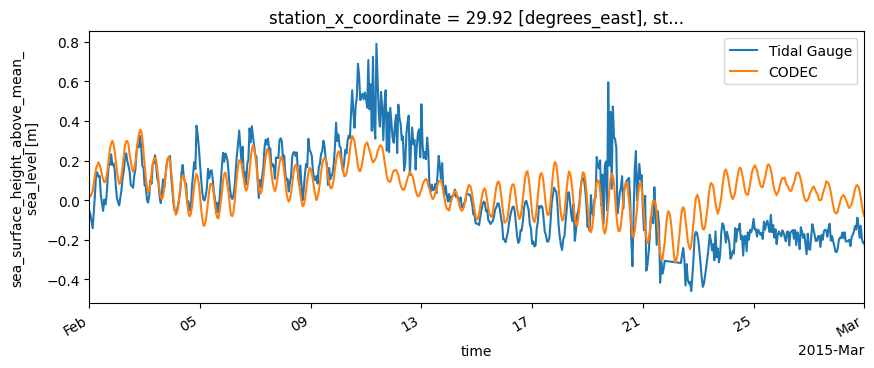

In [ ]:
from datetime import date

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
alexandria_tidal_gauge["SeaLevel-MSL"].plot(figsize=(10, 4), label="Tidal Gauge", ax=ax)
alexandria_codec.waterlevel.plot(label="CODEC", ax=ax)
ax.legend()
ax.set_xlim(date(2015, 2, 1), date(2015, 3, 1))